In [1]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

In [2]:
def load_pickle(file):
    """
    load a pickle file into a local variable
    can be a pandas dataframe or dictionary
    """
    pickle_in = open(file, "rb")
    pickle_file = pickle.load(pickle_in)
    pickle_in.close()
    return pickle_file

In [3]:
noises = [0, 5, 10, 15, 20]
len_period = 20
node_dict = load_pickle('node_dictionary.pickle')
input_nodes = node_dict['GENETIC'] + node_dict['MOLECULAR'] + node_dict['PET'] + node_dict['MRI'] + node_dict['RISKFACTORS']

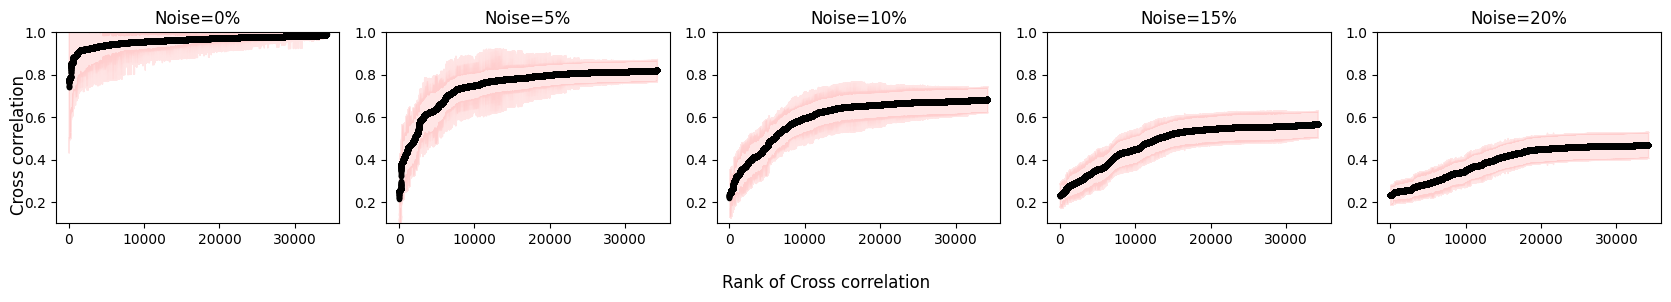

In [4]:
fig, axes = plt.subplots(1, len(noises), figsize=(17,3))
for k, noise in enumerate(noises):
    cross_corr = {'mean': [], 'std': []}
    for in_node in input_nodes:
        file = f'../results_pearson/network_paths/{in_node}/period_{len_period}/cross_corr_noise_{noise}.pickle'
        in_cross = load_pickle(file)
        cross_corr['mean'].append(in_cross['mean'].to_numpy())
        cross_corr['std'].append(in_cross['std'].to_numpy())
    total_mean = np.mean(np.array([i for i in cross_corr['mean']]), axis=0)
    total_std = np.mean(np.array([i for i in cross_corr['std']]), axis=0)
    n = total_mean.shape[0]
    list_mean = []
    list_std = []
    for i in range(n):
        for j in range(n):
            if i < j:
                list_mean.append(total_mean[i][j])
                list_std.append(total_std[i][j])
    sorted_list_mean_indices = sorted(range(len(list_mean)), key=lambda k: list_mean[k])
    sorted_list_std = [list_std[i] for i in sorted_list_mean_indices]
    list_mean.sort()
    mean_array = np.array(list_mean)
    std_array = np.array(sorted_list_std)
    ax = axes[k]
    x = np.linspace(0, len(list_mean), len(list_mean))
    ax.plot(x, mean_array, 'k.')
    # Plot the red cloud representing the standard deviation
    ax.fill_between(x, mean_array-std_array, mean_array+std_array, color='red', alpha=0.1)
    ax.set_title(f'Noise={noise}%')
    ax.set_ylim(0.1, 1)
fig.supylabel('Cross correlation')
fig.supxlabel('Rank of Cross correlation')
plt.tight_layout()
plt.savefig('../imagenes/noise.png', dpi=600)
plt.show()